# Step 4 - Dynamic Intervention + Summary Visuals

基于 Step3 结果自动生成 hub 基因集合并运行动态干预。

- hub 由 Step3 输出自动汇总
- 不使用任何预设 anchor

In [ ]:
from pathlib import Path
import subprocess
import pandas as pd

ROOT = Path.cwd().resolve().parent.parent if Path.cwd().name == "example_sccrc_icb_step_by_step" else Path.cwd().resolve()
STEP2 = ROOT / "results" / "examples" / "sccrc_icb" / "step2"
STEP3 = ROOT / "results" / "examples" / "sccrc_icb" / "step3"
STEP4 = ROOT / "results" / "examples" / "sccrc_icb" / "step4"
STEP4.mkdir(parents=True, exist_ok=True)

hub_scores = {}
for f in sorted(STEP3.glob("interaction_targets_*.csv")):
    df = pd.read_csv(f)
    if "target_priority_score" not in df.columns:
        continue
    df = df.sort_values("target_priority_score", ascending=False)
    for col in ["ligand", "receptor"]:
        if col not in df.columns:
            continue
        for _, row in df.head(20).iterrows():
            g = str(row[col]).upper()
            s = float(row.get("target_priority_score", 0.0))
            hub_scores[g] = max(hub_scores.get(g, 0.0), s)

if not hub_scores:
    rank_path = STEP3 / "data_driven_targets_top20.csv"
    if rank_path.exists():
        top = pd.read_csv(rank_path).head(3)
        hub_genes = [str(x).upper() for x in top["gene"].tolist()]
    else:
        raise RuntimeError("No dynamic hubs or fallback targets available.")
else:
    hub_genes = [g for g, _ in sorted(hub_scores.items(), key=lambda x: x[1], reverse=True)[:3]]

hub_arg = ",".join(hub_genes)
print("Data-driven hub genes:", hub_genes)

cmd = [
    "python", "scripts/run_step4.py",
    "--step2-dir", str(STEP2),
    "--step3-dir", str(STEP3),
    "--output-dir", str(STEP4),
    "--hub-genes", hub_arg,
    "--combo-max-size", "2",
]
print(" ".join(cmd))
subprocess.run(cmd, cwd=ROOT, check=True)
print(f"Step4 done -> {STEP4}")

Step4 combo synergy figure generated locally


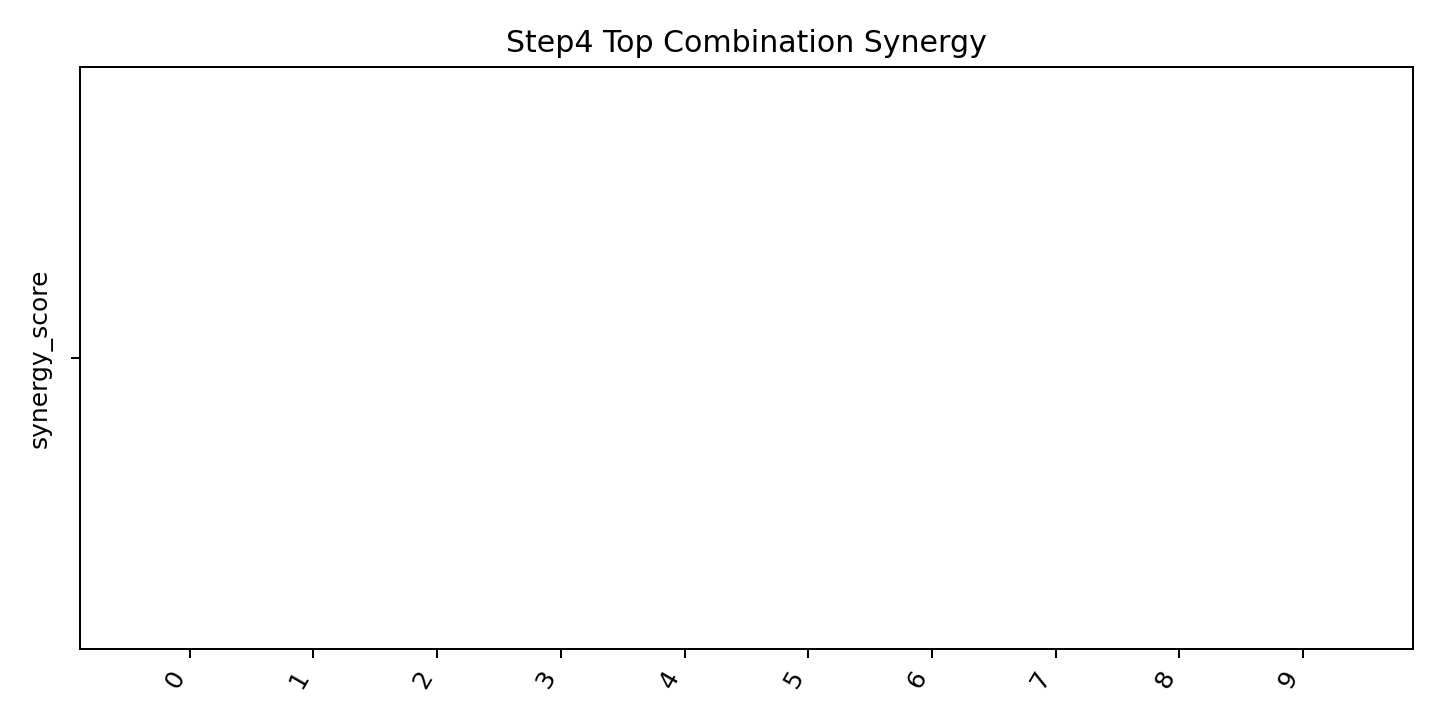

In [1]:
import json
import matplotlib.pyplot as plt
import pandas as pd

combo_path = STEP4 / "combination_ranking.csv"
if combo_path.exists():
    combo = pd.read_csv(combo_path).head(10)
    display(combo)
    if "synergy_score" in combo.columns:
        fig, ax = plt.subplots(figsize=(8, 4))
        x = combo.get("combo_name", combo.index.astype(str))
        ax.bar(x, combo["synergy_score"])
        ax.set_xticklabels(x, rotation=60, ha="right")
        ax.set_title("Top combination synergy (Step4)")
        ax.set_ylabel("synergy_score")
        plt.tight_layout()
        plt.show()
else:
    print("No combination_ranking.csv found.")

pkpd_path = STEP4 / "pkpd_summary.json"
if pkpd_path.exists():
    pkpd = json.loads(pkpd_path.read_text(encoding="utf-8"))
    print("PK/PD summary:")
    print(json.dumps(pkpd, ensure_ascii=False, indent=2))